In [38]:
import os
print(os.getcwd())
print(os.listdir("."))

c:\Users\Hp\Downloads\EBM-NLP
['.conda', '.git', '.gitattributes', 'axis1B_BioBERT_pred.csv', 'axis1B_PubMedBERT_pred.csv', 'axis2A_Few_Shot_qwen_pred.csv', 'axis2A_Zero_Shot_qwen_pred.csv', 'Axis2B_FULL_SUBMISSION.csv', 'ebm_nlp_1_00', 'ebm_nlp_1_00.tar.gz', 'ebm_nlp_2_00', 'ebm_nlp_2_00.tar.gz', 'ebm_nlp_demo.py', 'ebm_nlp_difficulty.tar.gz', 'EVALMETR.ipynb', 'generate_bio_labels.py', 'gold_structured.csv', 'models', 'notebooks', 'phase1_example.png', 'README.md', 'README.txt', 'results_axis1A_rule_based.csv', 'TASK2-EVALUATION Draft.ipynb', 'TASK2-EVALUATION.ipynb', 'task2_ebm-nlp edited.ipynb']


In [39]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

pio_fields = ["participants", "interventions", "outcomes"]

DATA_DIR = Path("./ebm_nlp_2_00")


# ----------------------------
# get official test doc ids
# ----------------------------

def get_doc_ids(split="test", label_type="participants"):
    if split == "test":
        split = "test/gold"

    folder = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "starting_spans"
        / label_type
        / split
    )

    doc_ids = [p.stem.split(".")[0] for p in folder.glob("*.AGGREGATED.ann")]
    return sorted(doc_ids)


test_doc_ids_p = get_doc_ids("test", "participants")
test_doc_ids_i = get_doc_ids("test", "interventions")
test_doc_ids_o = get_doc_ids("test", "outcomes")

# safest final choice: docs that exist in all three fields
test_doc_ids = sorted(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))

print("Participants test docs:", len(test_doc_ids_p))
print("Interventions test docs:", len(test_doc_ids_i))
print("Outcomes test docs:", len(test_doc_ids_o))
print("Common test docs used for final gold:", len(test_doc_ids))


# ----------------------------
# build gold csv
# ----------------------------

def get_spans(tokens, labels):
    spans = []
    current = []

    for tok, lab in zip(tokens, labels):
        lab = int(lab)

        if lab != 0:
            current.append(tok)
        else:
            if current:
                spans.append(" ".join(current))
                current = []

    if current:
        spans.append(" ".join(current))

    return spans


def read_tokens(doc_id):
    path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]


def read_labels(doc_id, field, split="test"):
    if split == "test":
        split = "test/gold"

    path = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "starting_spans"
        / field
        / split
        / f"{doc_id}.AGGREGATED.ann"
    )

    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]


def build_one_doc(doc_id):
    tokens = read_tokens(doc_id)

    row = {"doc_id": str(doc_id)}

    for field in pio_fields:
        labels = read_labels(doc_id, field)
        spans = get_spans(tokens, labels)

        # remove exact duplicates but keep order
        seen = set()
        clean_spans = []
        for s in spans:
            if s not in seen:
                seen.add(s)
                clean_spans.append(s)

        row[f"{field}_gold"] = " ; ".join(clean_spans)

    return row


def build_gold(doc_ids):
    rows = []

    for d in doc_ids:
        try:
            rows.append(build_one_doc(d))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    return pd.DataFrame(rows)


gold_df = build_gold(test_doc_ids)
gold_df.to_csv("gold_structured.csv", index=False)

print("Gold csv saved.")
print(gold_df.head())


# ----------------------------
# prep prediction csvs
# ----------------------------

def scrub_text(txt):
    if pd.isna(txt):
        return ""

    txt = str(txt).strip()

    # clean list-like leftovers if any
    if txt.startswith("[") and txt.endswith("]"):
        txt = txt[1:-1]

    # normalise separators a bit
    txt = txt.replace(";", " ; ")
    txt = re.sub(r"\s+", " ", txt).strip()

    # treat common non-values as empty
    if txt.lower() in {"none", "nan", "mixed"}:
        return ""

    return txt

def scrub_text(txt):
    if pd.isna(txt):
        return ""

    txt = str(txt).lower().strip()

    # remove brackets
    txt = txt.replace("[", "").replace("]", "")

    # unify separators
    txt = txt.replace("|", " ; ")
    txt = txt.replace(",", " ; ")

    # remove punctuation
    txt = re.sub(r"[^\w\s;]", " ", txt)

    # normalize spacing
    txt = re.sub(r"\s+", " ", txt).strip()

    return txt


def join_gold_and_preds(gold_csv_path, pred_csv_path, variant_label):
    gold_tab = pd.read_csv(gold_csv_path, dtype={"doc_id": str})
    pred_tab = pd.read_csv(pred_csv_path, dtype={"doc_id": str})

    for col in ["participants_pred", "interventions_pred", "outcomes_pred"]:
        if col in pred_tab.columns:
            pred_tab[col] = pred_tab[col].apply(scrub_text)

    # keep all official test docs
    merged = gold_tab.merge(pred_tab, on="doc_id", how="left")

    for col in ["participants_pred", "interventions_pred", "outcomes_pred"]:
        if col not in merged.columns:
            merged[col] = ""
        merged[col] = merged[col].fillna("")

    merged["variant"] = variant_label

    return merged


def stack_variants(list_of_tabs):
    return pd.concat(list_of_tabs, ignore_index=True)


def check_expected_columns(tab, fields):
    needed = ["doc_id", "variant"]

    for fld in fields:
        needed.append(f"{fld}_gold")
        needed.append(f"{fld}_pred")

    missing = [c for c in needed if c not in tab.columns]

    if missing:
        print("Missing columns:")
        for c in missing:
            print("-", c)
    else:
        print("All expected columns are present.")


# ----------------------------
# merge current model csvs
# ----------------------------

tab_rule = join_gold_and_preds(
    "gold_structured.csv",
    "./results_axis1A_rule_based.csv",
    "rule_based"
)

tab_decomposed = join_gold_and_preds(
    "gold_structured.csv",
    "./Axis2B_FULL_SUBMISSION.csv",
    "decomposed"
)

tab_biobert = join_gold_and_preds(
    "gold_structured.csv",
    "./axis1B_BioBERT_pred.csv",
    "biobert"
)

tab_pubmedbert = join_gold_and_preds(
    "gold_structured.csv",
    "./axis1B_PubMedBERT_pred.csv",
    "pubmedbert"
)

tab_fewshot_qwen = join_gold_and_preds(
    "gold_structured.csv",
    "./axis2A_Few_Shot_qwen_pred.csv",
    "fewshot_qwen"
)

tab_zeroshot_qwen = join_gold_and_preds(
    "gold_structured.csv",
    "./axis2A_Zero_Shot_qwen_pred.csv",
    "zeroshot_qwen"
)

all_runs = stack_variants([
    tab_rule,
    tab_decomposed,
    tab_biobert,
    tab_pubmedbert,
    tab_fewshot_qwen,
    tab_zeroshot_qwen
])

check_expected_columns(all_runs, pio_fields)

print(all_runs["variant"].value_counts())
print(all_runs.head())

Participants test docs: 189
Interventions test docs: 188
Outcomes test docs: 190
Common test docs used for final gold: 186
Gold csv saved.
     doc_id                                  participants_gold  \
0  10070173  seasonal allergic rhinitis . ; seasonal allerg...   
1  10390665  children . ; tonsillectomy with or without ade...   
2  10475150  healthy volunteers and in patients with primar...   
3  10578479  premenopausal women . ; 36 premenopausal women...   
4  10589810  supportive periodontal therapy ( SPT ) . ; dur...   

                                  interventions_gold  \
0  budesonide Turbuhaler ; budesonide aqua ; bude...   
1                         granisetron ; perphenazine   
2  somatostatin ( octreotide ) ; Somatostatin ; s...   
3                   soy ; normal diet ; soy beverage   
4  conventional steel ; non-tooth substance remov...   

                                       outcomes_gold  
0  patients ' preferences for the two nasal devic...  
1  Anti-emetic ef

In [11]:
##evaluation

#exact match
def exact_m(gold_txt,pred_txt):
    g=scrub_text(gold_txt)
    p=scrub_text(pred_txt)
    return int(g != "" and g==p)

#1.token overlap F1
def overlap_f1(gold_txt, pred_txt):
#match on overlapping token
   g=scrub_text(gold_txt)
   p=scrub_text(pred_txt)

   if g== "" and p== "":
    return 1.0
   if g== "" or p== "":
    return 0.0

   gold_tkn=g.split()
   pred_tkn=p.split()

   gold_count=defaultdict(int)
   pred_count=defaultdict(int)

   for w in gold_tkn:
      gold_count[w] +=1
   for w in pred_tkn:
      pred_count[w] +=1

   shared=0
   for w in gold_count:
       shared =shared + min(gold_count[w],pred_count[w])

   if shared==0:
       return 0.0

   prec=shared/len(pred_tkn)
   rec=shared/len(gold_tkn)

   return 2*prec*rec/(prec+rec)

In [12]:
#evaluate one field
def evaluate_1field(tab,gold_col,pred_col,match_threshold=0.5):

    #calculate metrics 
    gold_nonempty=0
    pred_nonempty=0
    covered=0
    tp=0
    fp=0
    fn=0
    exact_score=[]
    s_score=[]

    for _, row in tab.iterrows():
        g=scrub_text(row[gold_col])
        p=scrub_text(row[pred_col])
        exact_score.append(exact_m(g,p))
        #partial match
        s_score.append(overlap_f1(g,p))


        #checks if predicted the answer and if its true
        has_gold=g!= ""
        has_pred=p!= ""
        if has_gold:
            gold_nonempty+=1
        if has_pred:
            pred_nonempty+=1
        if has_gold and has_pred:
            covered+=1

        #check if prediction is close enough to overlap_f1
        good=overlap_f1(g,p)>=match_threshold
        if has_gold and has_pred and good:
            tp+=1
        elif has_pred and (not has_gold or not good):
            fp+=1
        if has_gold and (not has_pred or not good):
            fn+=1

        precision=tp/(tp+fp) if (tp+fp)>0 else 0.0
        recall=tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1=2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
        coverage=covered/gold_nonempty if gold_nonempty>0 else 0.0

        return{"field":gold_col.replace("_gold",""),"exact_match":np.mean(exact_score),
               "avg_overlap_f1":np.mean(s_score),"precision":precision,
               "recall":recall, "f1":f1, "coverage":coverage}
    
    

        

In [40]:
#evaluate one variant
def eval_variant(tab,fields,variant_name=None, match_threshold=0.5):
    #evaluate across all fields
    rows=[]
    if variant_name is None:
        variant_name=tab["variant"].iloc[0] if "variant" in tab.columns else "unknown"
    for fld in fields:
        row=evaluate_1field(tab, gold_col=f"{fld}_gold", pred_col=f"{fld}_pred",
                            match_threshold=match_threshold)
        row["variant"]=variant_name
        rows.append(row)

    output=pd.DataFrame(rows)
    overall={"variant":variant_name, "field":"overall_avg","exact_match":output["exact_match"].mean(),
           "avg_overlap_f1":output["avg_overlap_f1"].mean(),"precision":output["precision"].mean(),
           "recall":output["recall"].mean(),"f1":output["f1"].mean(),"coverage":output["coverage"].mean()}
    return pd.concat([output,pd.DataFrame([overall])], ignore_index=True)


#evaluating all variants
def evaluate_all_variants(all_tab, fields,match_threshold=0.5):
    results=[]
    for name,sub in all_tab.groupby("variant"):
        res=eval_variant(sub, fields,name,match_threshold)
        results.append(res)
    return pd.concat(results,ignore_index=True)

#plot coverage v precision
def plot_cvp(score_tab):
    show=score_tab[score_tab["field"] !="overall_avg"]
    plt.figure(figsize=(7,5))
    for name,grp in show.groupby("variant"):
        plt.scatter(grp["coverage"],grp["precision"], label=name)
    
    plt.xlabel("Coverage")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.show()

In [42]:
##3.downstream usability

#making table
def make_q_table(tab,use_pred=False):
    suffix="_pred" if use_pred else "_gold"
    small_tab=tab[["doc_id", f"participants{suffix}", f"interventions{suffix}",
                   f"outcomes{suffix}"]].copy()
    small_tab.columns=["doc_id","participants","interventions","outcomes"]
    return small_tab

#scoring one doc for one query
def score_1doc(row,must_have):
    score=0
    for field,words in must_have.items():
        text=scrub_text(row[field])

        for w in words:
            w2=scrub_text(w)
            if re.search(rf"\b{re.escape(w2)}\b",text):
                score+=1
    return score

#rank doc for one query
def rank_doc(tab,must_have):
    work=tab.copy()
    work["score"]=work.apply(lambda row:score_1doc(row,must_have),axis=1)
    work=work[work["score"]>0].copy()
    work=work.sort_values(["score","doc_id"],ascending=[False, True])
    return work[["doc_id","score"]]

#one ranked query for one method
def eval_1rq(gold_tab,pred_tab,query_item,top_k=10):
    gold_rank=rank_doc(gold_tab,query_item["must_have"])
    pred_rank=rank_doc(pred_tab,query_item["must_have"])

    gold_top=set(gold_rank.head(top_k)["doc_id"].tolist())
    pred_top=set(pred_rank.head(top_k)["doc_id"].tolist())
    tp=len(gold_top&pred_top)
    fp=len(pred_top-gold_top)
    fn=len(gold_top-pred_top)

    precision=tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall=tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1=2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    return{"query":query_item["name"],"precision":precision,"recall":recall,"f1":f1,
           "gold_matches":len(gold_top),"pred_matches":len(pred_top)}






In [43]:
#all queries for one method
def eval_qranked(gold_tab,pred_tab,queries,top_k=10):
    rows=[]
    for q in queries:
        row=eval_1rq(gold_tab,pred_tab,q,top_k=top_k)
        rows.append(row)
    output=pd.DataFrame(rows)

    overall=pd.DataFrame([{"query":"overall","precision":output["precision"].mean(),
                           "recall":output["recall"].mean(),"f1":output["f1"].mean(),
                           "gold_matches":output["gold_matches"],"pred_matches":output["pred_matches"].sum()}])
    return pd.concat([output,overall],ignore_index=True)

#evaluate all method
def eval_q_allvariant(all_tab,queries,top_k=10):
    all_rows=[]
    for v_name,sub_tab in all_tab.groupby("variant"):
        gold_q=make_q_table(sub_tab, use_pred=False)
        pred_q=make_q_table(sub_tab,use_pred=True)
        res=eval_qranked(gold_q,pred_q,queries,top_k=top_k)
        res["variant"]=v_name
        all_rows.append(res)
    return pd.concat(all_rows,ignore_index=True)



In [46]:
pivot_full = field_scores.pivot_table(
    index="field",
    columns="variant",
    values=["precision", "recall", "f1"]
)

display(pivot_full.round(3))

f1                                                \
variant       biobert decomposed fewshot_qwen pubmedbert rule_based   
field                                                                 
interventions     0.0        0.0        0.000        0.0        0.0   
outcomes          0.0        0.0        0.000        0.0        0.0   
overall_avg       0.0        0.0        0.333        0.0        0.0   
participants      0.0        0.0        1.000        0.0        0.0   

                            precision                                     \
variant       zeroshot_qwen   biobert decomposed fewshot_qwen pubmedbert   
field                                                                      
interventions         0.000       0.0        0.0        0.000        0.0   
outcomes              0.000       0.0        0.0        0.000        0.0   
overall_avg           0.333       0.0        0.0        0.333        0.0   
participants          1.000       0.0        0.0        1.000        0.0   

                                        recall                          \
variant       rule_based zeroshot_qwen biobert decomposed fewshot_qwen   
field                                                                    
interventions        0.0         0.000     0.0        0.0        0.000   
outcomes             0.0         0.000     0.0        0.0        0.000   
overall_avg          0.0         0.333     0.0        0.0        0.333   
participants         0.0         1.000     0.0        0.0        1.000   

                                                   
variant       pubmedbert rule_based zeroshot_qwen  
field                                              
interventions        0.0        0.0         0.000  
outcomes             0.0        0.0         0.000  
overall_avg          0.0        0.0         0.333  
participants         0.0        0.0         1.000

In [47]:
display(field_scores.round(3))

pivot = field_scores.pivot_table(
    index="field",
    columns="variant",
    values="f1"
)
display(pivot.round(3))

,field,exact_match,avg_overlap_f1,precision,recall,f1,coverage,variant
0,participants,0.0,0.292,0.000,0.000,0.000,1.000,biobert
1,interventions,0.0,0.379,0.000,0.000,0.000,1.000,biobert
2,outcomes,0.0,0.194,0.000,0.000,0.000,1.000,biobert
3,overall_avg,0.0,0.288,0.000,0.000,0.000,1.000,biobert
4,participants,0.0,0.000,0.000,0.000,0.000,0.000,decomposed
5,interventions,0.0,0.389,0.000,0.000,0.000,1.000,decomposed
6,outcomes,0.0,0.255,0.000,0.000,0.000,1.000,decomposed
7,overall_avg,0.0,0.214,0.000,0.000,0.000,0.667,decomposed
8,participants,0.0,0.689,1.000,1.000,1.000,1.000,fewshot_qwen
9,interventions,0.0,0.231,0.000,0.000,0.000,1.000,fewshot_qwen


variant,biobert,decomposed,fewshot_qwen,pubmedbert,rule_based,zeroshot_qwen
field,,,,,,
interventions,0.0,0.0,0.000,0.0,0.0,0.000
outcomes,0.0,0.0,0.000,0.0,0.0,0.000
overall_avg,0.0,0.0,0.333,0.0,0.0,0.333
participants,0.0,0.0,1.000,0.0,0.0,1.000


In [48]:
field_scores = evaluate_all_variants(all_runs, pio_fields, match_threshold=0.5)

compare_all = field_scores.pivot_table(
    index="field",
    columns="variant",
    values=["exact_match", "avg_overlap_f1", "precision", "recall", "f1", "coverage"]
)

display(compare_all.round(3))

avg_overlap_f1                                                \
variant              biobert decomposed fewshot_qwen pubmedbert rule_based   
field                                                                        
interventions          0.379      0.389        0.231      0.326      0.077   
outcomes               0.194      0.255        0.182      0.369      0.282   
overall_avg            0.288      0.214        0.367      0.338      0.166   
participants           0.292      0.000        0.689      0.320      0.140   

                            coverage                                     ...  \
variant       zeroshot_qwen  biobert decomposed fewshot_qwen pubmedbert  ...   
field                                                                    ...   
interventions         0.286      1.0      1.000          1.0        1.0  ...   
outcomes              0.259      1.0      1.000          1.0        1.0  ...   
overall_avg           0.411      1.0      0.667          1.0        1.0  ...   
participants          0.689      1.0      0.000          1.0        1.0  ...   

                 precision                                      recall  \
variant       fewshot_qwen pubmedbert rule_based zeroshot_qwen biobert   
field                                                                    
interventions        0.000        0.0        0.0         0.000     0.0   
outcomes             0.000        0.0        0.0         0.000     0.0   
overall_avg          0.333        0.0        0.0         0.333     0.0   
participants         1.000        0.0        0.0         1.000     0.0   

                                                                           
variant       decomposed fewshot_qwen pubmedbert rule_based zeroshot_qwen  
field                                                                      
interventions        0.0        0.000        0.0        0.0         0.000  
outcomes             0.0        0.000        0.0        0.0         0.000  
overall_avg          0.0        0.333        0.0        0.0         0.333  
participants         0.0        1.000        0.0        0.0         1.000  

[4 rows x 36 columns]

In [ ]:
query_score_all = eval_q_allvariant(all_runs, queries, top_k=10)
print(query_score_all)

                          query  precision    recall        f1  \
0         diabetes participants   1.000000  0.166667  0.285714   
1        exercise interventions   0.750000  0.750000  0.750000   
2       blood pressure outcomes   0.750000  1.000000  0.857143   
3       diabetes and metaformin   1.000000  0.166667  0.285714   
4   exercise and blood pressure   0.700000  0.700000  0.700000   
5                       overall   0.840000  0.556667  0.575714   
6         diabetes participants   1.000000  0.166667  0.285714   
7        exercise interventions   0.500000  0.250000  0.333333   
8       blood pressure outcomes   0.666667  1.000000  0.800000   
9       diabetes and metaformin   1.000000  0.166667  0.285714   
10  exercise and blood pressure   0.600000  0.600000  0.600000   
11                      overall   0.753333  0.436667  0.460952   

                                         gold_matches  pred_matches  \
0                                                   6             1   

In [50]:
sub = all_runs[all_runs["variant"] == "biobert"].head(5)

for _, row in sub.iterrows():
    print("GOLD:", row["participants_gold"])
    print("PRED:", row["participants_pred"])
    print("OVERLAP:", overlap_f1(row["participants_gold"], row["participants_pred"]))
    print("----")

GOLD: seasonal allergic rhinitis . ; seasonal allergic rhinitis ( SAR ) . ; Ontario , Quebec and Manitoba . ; Two hundred and eighty-four out-patients with SAR , who were symptomatic during the ragweed season , volunteered for enrolment ( 243 randomized ) . ; SAR .
PRED: sar ; who were symptomatic during; volunteered for
OVERLAP: 0.29166666666666663
----
GOLD: children . ; tonsillectomy with or without adenoidectomy in children . ; 90 paediatric patients , ASA I , aged 4-10 years ; children undergoing general anaesthesia for tonsillectomy .
PRED: asa i ; aged 4 10; received granisetron 40; kg 1 or perphenazine 70 mg
OVERLAP: 0.27906976744186046
----
GOLD: healthy volunteers and in patients with primary hypothyroidism . ; 8 healthy volunteers , and 6 women with untreated primary hypothyroidism ; healthy volunteers ; healthy controls ; The patients with hypothyroidism ; normal subjects and in patients with primary hypothyroidism
PRED: women; ; a; associated with increased nocturnal secre

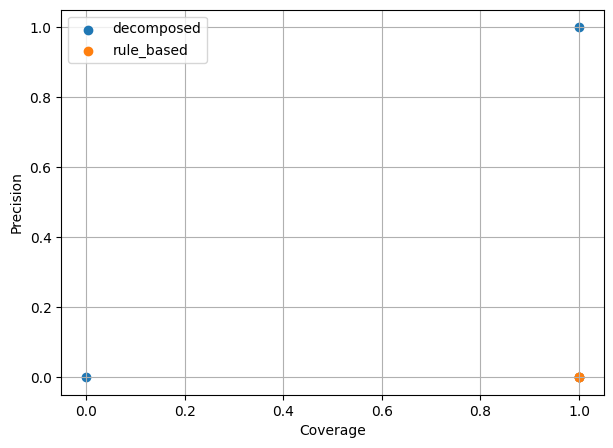

In [ ]:
'''plot_cvp(field_scores)'''

In [35]:
#queries
#example query

queries=[
    {"name":"diabetes participants","must_have":{"participants":["diabetes"]}},
    {"name":"exercise interventions","must_have":{"interventions":["exercise"]}},
    {"name":"blood pressure outcomes","must_have":{"outcomes":["blood pressure"]}},
    {"name":"diabetes and metaformin","must_have":{"participants":["diabetes"], "interventions":["metaformin"]}},
    {"name":"exercise and blood pressure","must_have":{"interventions":["exercise"],"outcomes":["blood pressure"]}}
    
]

#all run defined when i get csv file
query_score_all=eval_q_allvariant(all_runs,queries,top_k=10)
print(query_score_all)

                          query  precision    recall        f1  \
0         diabetes participants   1.000000  0.166667  0.285714   
1        exercise interventions   0.750000  0.750000  0.750000   
2       blood pressure outcomes   0.750000  1.000000  0.857143   
3       diabetes and metaformin   1.000000  0.166667  0.285714   
4   exercise and blood pressure   0.700000  0.700000  0.700000   
5                       overall   0.840000  0.556667  0.575714   
6         diabetes participants   1.000000  0.166667  0.285714   
7        exercise interventions   0.500000  0.250000  0.333333   
8       blood pressure outcomes   0.666667  1.000000  0.800000   
9       diabetes and metaformin   1.000000  0.166667  0.285714   
10  exercise and blood pressure   0.600000  0.600000  0.600000   
11                      overall   0.753333  0.436667  0.460952   

                                         gold_matches  pred_matches  \
0                                                   6             1   

In [ ]:
'''print(all_runs.shape)
print(all_runs["variant"].value_counts())
for name, sub in all_runs.groupby("variant"):
    print(name, len(sub))'''

(372, 8)
variant
rule_based    186
decomposed    186
Name: count, dtype: int64
decomposed 186
rule_based 186


In [ ]:
#print(all_runs[[
    "participants_gold",
    "participants_pred"
]].head(10))

                                   participants_gold  \
0  seasonal allergic rhinitis . ; seasonal allerg...   
1  children . ; tonsillectomy with or without ade...   
2  healthy volunteers and in patients with primar...   
3  premenopausal women . ; 36 premenopausal women...   
4  supportive periodontal therapy ( SPT ) . ; dur...   
5  after nose surgery ; 61 inpatients with the di...   
6  abdominal surgery . ; patients who underwent h...   
7  treated hypertensive patients . ; hypertensive...   
8  children with pervasive developmental disorder...   
9  dogs and cats presented as veterinary patients...   

                                   participants_pred  
0                                  patients with SAR  
1                                    aged 4-10 years  
2  6 women | patients with primary hypothyroidism...  
3                                                     
4                          40 subjects | 20 subjects  
5  30 patients | patients with the diagnosis Rhin... 